# Surface geostrophic velocities calculated from sea level

This recipe uses sea level ($\eta$) to calculate surface geostrophic velocities ($\mathbf{u}$) using the following relation:

$$
\mathbf{u_{g,s}} = \frac{g}{f} \mathbf{\hat{z}} \times \nabla \eta
$$

which can be re-written for the zonal and meridional directions as follows:

$$
    u_{g,s} = -\frac{g}{f}\frac{\partial \eta}{\partial y} \quad \textrm{and} \quad
    v_{g,s} = \frac{g}{f}\frac{\partial \eta}{\partial x}
$$

where $u_{g,s}$ and $v_{g,s}$ are the geostrophic velocities at the surface, $g$ is the acceleration due to gravity, $f$ is the Coriolis parameter and $\eta$ is the sea surface.

This recipe also compares surface geostrophic velocities to the model's diagnosed velocities - note that these will include geostrophic + ageostrophic contributions and thus we don't expect exact agreement.

---

### Requirements

This recipe works with MOM5. In order to adapt to MOM6, please consider the following equivalent diagnostics:

|MOM5 diagnostic (x-coord,y-coord) | Equivalent MOM6 diagnostic (x-coord,y-coord) | 
|:--------|-----|
| `sea_level(xt_ocean,yt_ocean)` | `zos(xh,yh)` | 
| `u(xu_ocean, yu_ocean)`|`uo(xq,yh)`|
|`v(xu_ocean, yu_ocean)` | `vo(yq,xh)` | 

Note that the velocities are not given in the same grid - while in MOM5 velocities are given in the cell corners, in MOM6 they are given in cell faces. You will have to interpolate - we recommend using `xgcm`. Remember to choose appropriate grid-size diagnostics.

In [1]:
import cmocean as cm
import gsw 
import intake
import matplotlib.pyplot as plt
import numpy as np 
import xgcm
import xarray as xr

from dask.distributed import Client

In [2]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43785 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43785/status,
Dashboard: http://127.0.0.1:43785/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32851,Workers: 0
Dashboard: http://127.0.0.1:43785/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40275,Total threads: 1
Dashboard: http://127.0.0.1:36305/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:40823,


Open ACCESS-NRI default catalog

In [3]:
catalog = intake.cat.access_nri

Load diagnostics needed - this recipe works with one month of daily data. We will select a small domain over a Subantarctic Front meander in the Antarctic Circumpolar Current.

In [34]:
experiment = '01deg_jra55v140_iaf_cycle3'

def select_region(ds):
    ds = ds.sel(xt_ocean=slice(-224.2, -212.0), yt_ocean=slice(-53.5,  -47.5))
    return ds

# Load sea level 
sea_level = catalog[experiment].search(variable='sea_level', 
                                       frequency='1day',
                                       start_date='2000-04.*').to_dask(preprocess=select_region)['sea_level']

def select_region(ds):
    ds = ds.sel(xu_ocean=slice(-224.2, -212.0), yu_ocean=slice(-53.5,  -47.5))
    return ds

# Load velocities (to compare to geostrophic velocities)
ds_vels = catalog[experiment].search(variable=['usurf', 'vsurf'], 
                                    frequency='1day', 
                                    start_date='2000-04.*').to_dask(preprocess=select_region)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='usurf' → variable=['usurf','usurf']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='vsurf' → variable=['vsurf','vsurf']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)


Load grid dimensions:

In [38]:
dxu = catalog[experiment].search(variable='dxu', 
                                 frequency='fx').to_dask(preprocess=select_region)
dyu = catalog[experiment].search(variable='dyu', 
                                 frequency='fx').to_dask(preprocess=select_region)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


We first need to create a `grid` object that has all the information regarding our staggered grid. For our case, `grid` needs to know the location of the `xt_ocean`, `xu_ocean` points (and same for $y$) and their relative orientation to one another, i.e., that `xu_ocean` is shifted to the right of `xt_ocean` by $\frac1{2}$ grid-cell.

`xgcm` also expects you to pass on grid information in which `xt_ocean`, `xu_ocean` are of the same length and staggered in the correct direction (`u` to the right of `t`) - and same for the y-direction. Lets check that.

In [40]:
ds = xr.merge([dxu, dyu, sea_level, ds_vels])
ds

<xarray.Dataset> Size: 13MB
Dimensions:    (yu_ocean: 94, xu_ocean: 122, xt_ocean: 122, yt_ocean: 95,
                time: 91)
Coordinates:
  * yu_ocean   (yu_ocean) float64 752B -53.46 -53.4 -53.34 ... -47.62 -47.56
  * xu_ocean   (xu_ocean) float64 976B -224.2 -224.1 -224.0 ... -212.2 -212.1
  * xt_ocean   (xt_ocean) float64 976B -224.1 -224.0 -223.9 ... -212.1 -212.0
  * yt_ocean   (yt_ocean) float64 760B -53.49 -53.43 -53.37 ... -47.59 -47.52
  * time       (time) datetime64[ns] 728B 2000-04-01T12:00:00 ... 2000-06-30T...
Data variables:
    dxu        (yu_ocean, xu_ocean) float32 46kB dask.array<chunksize=(94, 122), meta=np.ndarray>
    dyu        (yu_ocean, xu_ocean) float32 46kB dask.array<chunksize=(94, 122), meta=np.ndarray>
    sea_level  (time, yt_ocean, xt_ocean) float32 4MB dask.array<chunksize=(4, 95, 122), meta=np.ndarray>
    usurf      (time, yu_ocean, xu_ocean) float32 4MB dask.array<chunksize=(4, 94, 122), meta=np.ndarray>
    vsurf      (time, yu_ocean, xu_ocean) float32 4MB dask.array<chunksize=(4, 94, 122), meta=np.ndarray>
Attributes: (12/21)
    filename:                                 ocean-2d-dxu.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    history:                                  20201116T1058Z: /g/data/ik11/in...
    intake_esm_vars:                          ['dxu']
    ...                                       ...
    intake_esm_attrs:variable_cell_methods:   time: point,,,
    intake_esm_attrs:variable_units:          m,days since 1900-01-01 00:00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:temporal_label:          point
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.fx.xu_ocean:3600.yu_ocean...

We need to correct the staggering for the x-dimension:|

In [41]:
ds = ds.isel(xu_ocean=slice(1,None), xt_ocean=slice(None,-1))

In [42]:
ds.coords['xt_ocean'].attrs.update(axis='X')
ds.coords['xu_ocean'].attrs.update(axis='X', c_grid_axis_shift=0.5)
ds.coords['yt_ocean'].attrs.update(axis='Y')
ds.coords['yu_ocean'].attrs.update(axis='Y', c_grid_axis_shift=0.5)

grid = xgcm.Grid(ds, boundary='extend')
grid

<xgcm.Grid>
Y Axis (not periodic, boundary='extend'):
  * center   yt_ocean --> inner
  * inner    yu_ocean --> center
X Axis (not periodic, boundary='extend'):
  * center   xt_ocean --> right
  * right    xu_ocean --> center

Now we need to calculate the Coriolis parameter, and gravity. We can use the library `gsw` for that.

In [43]:
f = gsw.f(ds['yu_ocean'])
g = gsw.grav(ds['yu_ocean'], 0)

Now we are ready to calculate the geostrophic velocities:

In [44]:
# Sea level horizontal gradients
detadx = grid.interp(grid.diff(ds['sea_level'], 'X', boundary='extend'), 'Y', boundary='extend') / ds['dxu']
detady = grid.interp(grid.diff(ds['sea_level'], 'Y', boundary='extend'), 'X', boundary='extend') / ds['dyu']

ds['ug_s'] = - (g / f) * detady
ds['ug_s'].name = 'ug_s'
ds['ug_s'].attrs['standard_name'] = 'surface_geostrophic_eastward_sea_water_velocity'
ds['ug_s'].attrs['long_name'] = r'$u_g,s$'
ds['ug_s'].attrs['units'] = r'$\mathrm{ms}^{-1}$'

ds['vg_s'] =   (g / f) * detadx
ds['vg_s'].name = 'vg_s'
ds['vg_s'].attrs['standard_name'] = 'surface_geostrophic_northward_sea_water_velocity'
ds['vg_s'].attrs['long_name'] = r'$v_g,s$'
ds['vg_s'].attrs['units'] = r'$\mathrm{ms}^{-1}$'

Let's calculate the speed in order to plot:

In [45]:
Vg = np.sqrt(ds['ug_s']**2 + ds['vg_s']**2)

Let's do a nice plot with quivers and coloured by speed:

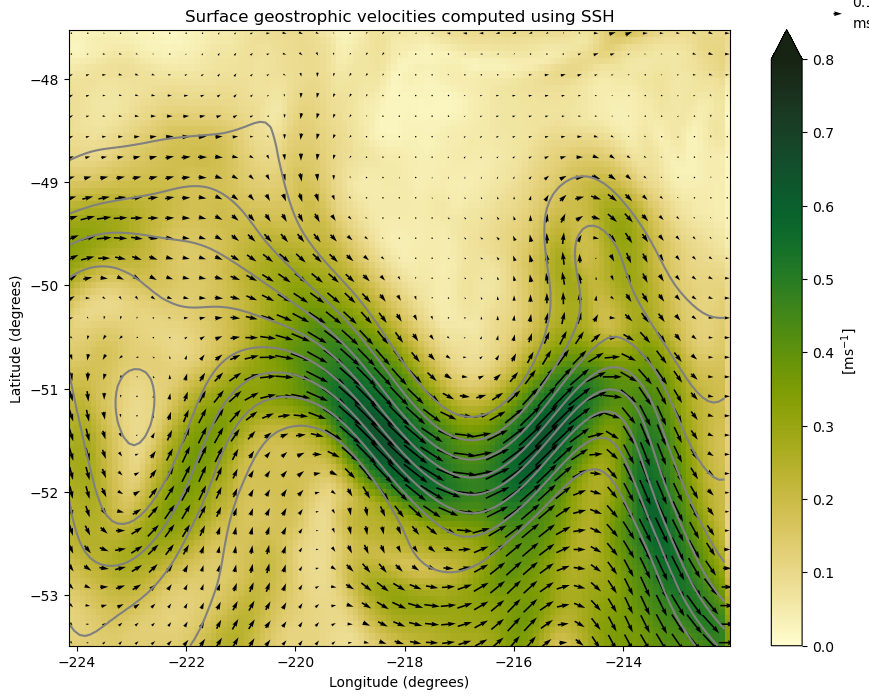

In [46]:
Vg.mean('time').plot(size=8,
                     cmap=cm.cm.speed, 
                     vmin=0, vmax=0.8, 
                     extend='max')
ds['sea_level'].mean('time').plot.contour(levels=np.linspace(-0.7, 0, 8), 
                                          colors='gray', 
                                          linestyles='solid')
ds.mean('time').sel(xu_ocean=slice(None, None, 3), yu_ocean=slice(None, None, 3)).plot.quiver(x='xu_ocean', 
                                                                                              y='yu_ocean', 
                                                                                              u='ug_s', 
                                                                                              v='vg_s')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude (degrees)')
plt.title('Surface geostrophic velocities computed using SSH');

As you can see, geostrophic velocities are parallel to sea level contours. Now let's compare them to the total surface velocities from the model's diagnostics:

In [47]:
V_s = np.sqrt(ds['usurf']**2 + ds['vsurf']**2)

ds['uag'] = ds['usurf'] - ds['ug_s']
ds['vag'] = ds['vsurf'] - ds['vg_s']

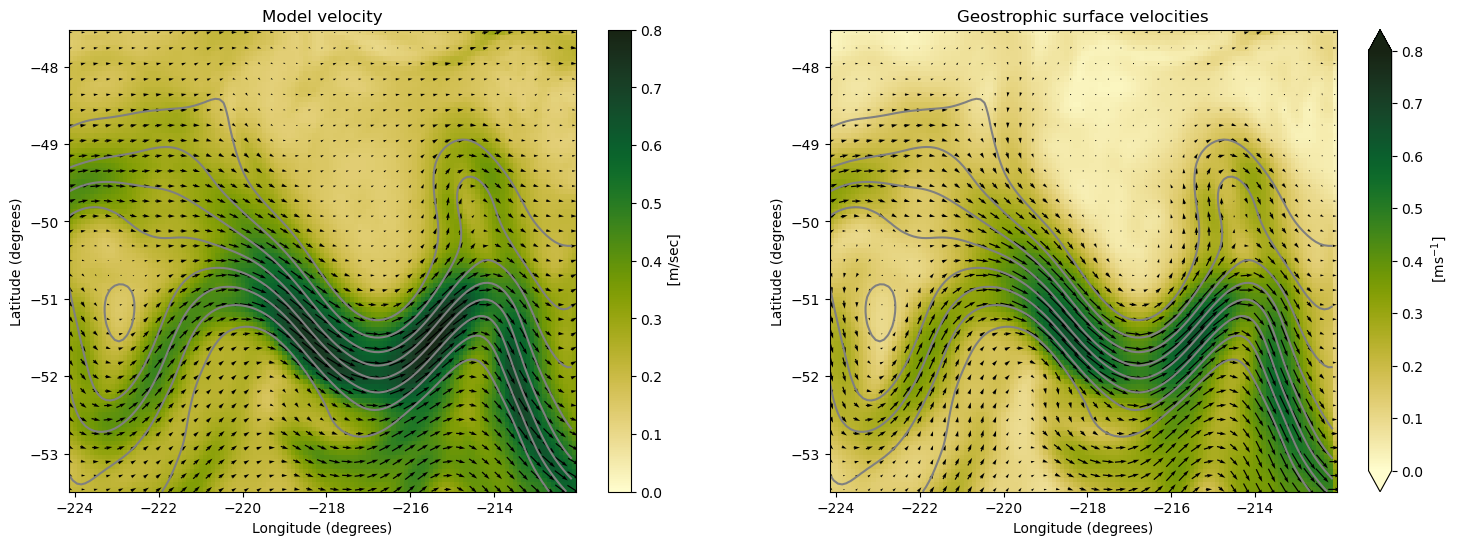

In [52]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Plot total flow speed
V_s.mean('time').plot(ax=axes[0], cmap=cm.cm.speed, vmin=0, vmax=0.8)

ds.mean('time').sel(xu_ocean=slice(None, None, 3), 
                    yu_ocean=slice(None, None, 3)).plot.quiver(ax=axes[0],
                                                            x='xu_ocean', y='yu_ocean',
                                                            u='usurf', v='vsurf',
                                                            add_guide = False)

# Plot ageostrophic flow speed
Vg.mean('time').plot(ax=axes[1], cmap=cm.cm.speed, vmin=0, vmax=0.8, extend='both')

ds.mean('time').sel(xu_ocean=slice(None, None, 3), 
                    yu_ocean=slice(None, None, 3)).plot.quiver(ax=axes[1],
                                                             x='xu_ocean', y='yu_ocean',
                                                             u='ug_s', v='vg_s',
                                                             add_guide = False)

for ax in axes:
    ds['sea_level'].mean('time').plot.contour(ax=ax,
                                            levels=np.linspace(-0.7, 0, 8),
                                            colors='gray',
                                            linestyles='solid')
    ax.set_xlabel('Longitude (degrees)')
    ax.set_ylabel('Latitude (degrees)')

axes[0].set_title('Model velocity')
axes[1].set_title('Geostrophic surface velocities');

You can see that these are not exactly the same - the model's diagnosed surface velocities include geostrophic and ageostrophic contributions. Nevertheless, geostrophic velocities make a considerable contribution to the total flow!

In [ ]:
client.close()